Assignment: Logistic Regression

Objective

The goal of this assignment is to understand and apply the Machine Learning (ML) pipeline using Logistic Regression for a binary classification problem.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, log_loss
)

import warnings
warnings.filterwarnings('ignore')

Task 1: Logistic Regression with a Single Feature

1. Data Retrieval and Collection

In [12]:
df = pd.read_csv(r'Heart_Disease_Prediction.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (270, 14)

Columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']

First 5 rows:


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [13]:
print('Dataset Info:')
df.info()
print('\nStatistical Summary:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


Binary outcome:
1 → Presence of heart disease
0 → No heart disease


 2. Data Cleaning

In [14]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
# Checking data types
print('\nData types:')
print(df.dtypes)
# Check if target variable is binary
print('\nHeart Disease unique values:', df['Heart Disease'].unique())
# Check for invalid cholesterol values (0 is medically invalid)
print('\nCholesterol == 0 count:', (df['Cholesterol'] == 0).sum())

Missing values per column:
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Data types:
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

Heart Disease unique values: ['Prese

In [15]:
# Handling invalid Cholesterol values (if 0, replace with median)
median_chol = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_chol)
# Dropping any remaining null rows
df.dropna(inplace=True)
print('Cleaned dataset shape:', df.shape)
print('Cholesterol min after cleaning:', df['Cholesterol'].min())

# Convert target to binary (0, 1)
df['Heart Disease'] = df['Heart Disease'].map({'Absence': 0, 'Presence': 1})

Cleaned dataset shape: (270, 14)
Cholesterol min after cleaning: 126


3. Feature Design

In [16]:
#Selecting Cholesterol as input since it can predict potential heart disease.
X1 = df[['Cholesterol']]
y1 = df['Heart Disease']

print('Feature shape:', X1.shape)
print('Target distribution:\n', y1.value_counts())

Feature shape: (270, 1)
Target distribution:
 Heart Disease
0    150
1    120
Name: count, dtype: int64


Cholesterol can predict cardiovascular disease because excess cholesterol can build up in artery walls, forming plaques that narrow or block blood vessels and increase the risk of heart-related conditions.


4. Algorithm Selection

    Choosing Logistic Regression.
    Logistic regression is suitable for binary classification for the following reasons:
    1. Outputs values strictly between 0 and 1.
    2. Uses an S-shaped curve(Sigmoid Function) to squeeze infinite numbers into a probability range.
    3. Easily interpretable as it clearly shows how much each input feature contributes to the final outcome.
    4. It is computationally efficient and works well as a baseline model.

5. Loss Function Selection

    Using Binary Cross-Entropy (Log Loss).Its working principle is explained below:

    Loss = -[y·log(ŷ) + (1-y)·log(1-ŷ)]

    1. If the actual class label y=1 and the predicted ŷ is close to 1, the loss value becomes very small, approaching zero.
    2. If the model assigns a high probability to the wrong class, the loss increases significantly, resulting in a strong penalty for confident mistakes.

6. Model Learning(Training)


In [17]:
# Train-test split (80/20)
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

print('Training samples:', X1_train.shape[0])
print('Testing samples:', X1_test.shape[0])

# Feature scaling (important for gradient-based optimization)
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled  = scaler1.transform(X1_test)

# Train Logistic Regression model
model1 = LogisticRegression(random_state=42)
model1.fit(X1_train_scaled, y1_train)

print('\nModel Coefficient (Cholesterol):', model1.coef_[0][0])
print('Model Intercept:', model1.intercept_[0]) 

Training samples: 216
Testing samples: 54

Model Coefficient (Cholesterol): 0.17648960959078797
Model Intercept: -0.2242275026845029


Model parameters are learned during training by minimizing a loss function. In logistic regression, the model learns its weights and bias by minimizing the log loss using gradient descent, which updates the parameters to improve prediction accuracy.

7. Model Evaluation


=== Task 1 Evaluation (Single Feature: Cholesterol) ===
Accuracy : 0.5741
Precision: 0.5714
Recall   : 0.1667
F1-Score : 0.2581
Log Loss : 0.6701

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.90      0.70        30
           1       0.57      0.17      0.26        24

    accuracy                           0.57        54
   macro avg       0.57      0.53      0.48        54
weighted avg       0.57      0.57      0.50        54



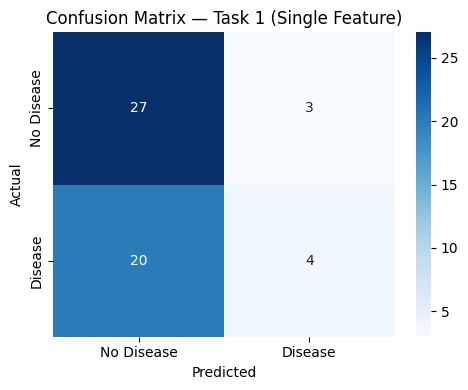

In [18]:
# Predictions
y1_pred  = model1.predict(X1_test_scaled)
y1_proba = model1.predict_proba(X1_test_scaled)[:, 1]

# Metrics
acc1  = accuracy_score(y1_test, y1_pred)
prec1 = precision_score(y1_test, y1_pred)
rec1  = recall_score(y1_test, y1_pred)
f11   = f1_score(y1_test, y1_pred)
ll1   = log_loss(y1_test, y1_proba)

print('=== Task 1 Evaluation (Single Feature: Cholesterol) ===')
print(f'Accuracy : {acc1:.4f}')
print(f'Precision: {prec1:.4f}')
print(f'Recall   : {rec1:.4f}')
print(f'F1-Score : {f11:.4f}')
print(f'Log Loss : {ll1:.4f}')
print('\nClassification Report:')
print(classification_report(y1_test, y1_pred))

#Printing Confusion Matrix
cm1 = confusion_matrix(y1_test, y1_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Task 1 (Single Feature)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Task 2: Logistic Regression with Multiple Features

1. Data Retrieval and Collection

In [19]:
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (270, 14)
Columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


2. Data Cleaning

In [20]:
# Already cleaned in Task 1
print('Missing values:', df.isnull().sum().sum())
print('Target distribution:\n', df['Heart Disease'].value_counts())

Missing values: 0
Target distribution:
 Heart Disease
0    150
1    120
Name: count, dtype: int64


3. Feature Design

In [21]:
# Separate features and target
X2 = df.drop(columns=['Heart Disease'])
y2 = df['Heart Disease']

# Identify categorical columns
cat_cols = X2.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', cat_cols)

# Encode categorical variables using Label Encoding
le = LabelEncoder()
for col in cat_cols:
    X2[col] = le.fit_transform(X2[col])

print('\nFeature types after encoding:')
print(X2.dtypes)
print('\nFeature shape:', X2.shape)

Categorical columns: []

Feature types after encoding:
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
dtype: object

Feature shape: (270, 13)


Using multiple features can improve prediction performance because different features provide complementary information about the target variable, allowing the model to capture more patterns and make more accurate predictions.

4. Algorithm Selection

    Logistic Regression just as task 1 with the only difference being the model uses multiple features(multivariate). It learns one weight per feature, forming a decision boundary in higher-dimensional space. 

5. Loss Function Selection

    Binary Cross-Entropy (Log Loss) just as task 1. However, the loss is now calculated based on the prediction generated from the combined effect of all input features, represented by the linear equation:
                                        
    z=w1x1+w2x2+⋯+wnxn+b

    This means that each feature contributes to the final prediction, and the loss reflects the model's performance using all features together.

6. Model Learning (Training)

In [22]:
# Train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Feature scaling
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled  = scaler2.transform(X2_test)

# Train Logistic Regression
model2 = LogisticRegression(max_iter=1000, random_state=42)
model2.fit(X2_train_scaled, y2_train)

# Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': X2.columns,
    'Coefficient': model2.coef_[0]
}).sort_values('Coefficient', ascending=False)
print('Feature Coefficients:')
print(coef_df.to_string(index=False))

Feature Coefficients:
                Feature  Coefficient
Number of vessels fluro     1.185769
                    Sex     0.892690
        Chest pain type     0.716115
               Thallium     0.584150
        Exercise angina     0.481365
            Slope of ST     0.413009
                     BP     0.408808
            Cholesterol     0.341274
          ST depression     0.240702
            EKG results     0.073109
                    Age     0.025068
           FBS over 120    -0.347914
                 Max HR    -0.399470


7. Model Evaluation

=== Task 2 Evaluation (Multiple Features) ===
Accuracy : 0.8519
Precision: 0.7857
Recall   : 0.9167
F1-Score : 0.8462
Log Loss : 0.4463

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



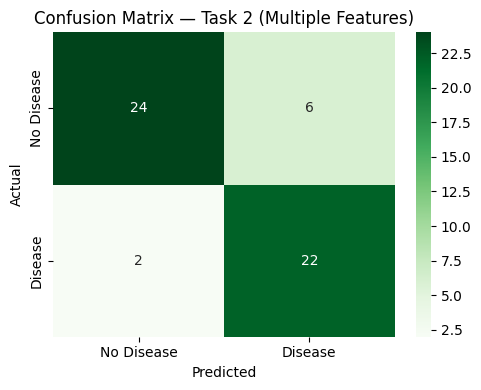

In [23]:
# Predictions
y2_pred  = model2.predict(X2_test_scaled)
y2_proba = model2.predict_proba(X2_test_scaled)[:, 1]

# Metrics
acc2  = accuracy_score(y2_test, y2_pred)
prec2 = precision_score(y2_test, y2_pred)
rec2  = recall_score(y2_test, y2_pred)
f12   = f1_score(y2_test, y2_pred)
ll2   = log_loss(y2_test, y2_proba)

print('=== Task 2 Evaluation (Multiple Features) ===')
print(f'Accuracy : {acc2:.4f}')
print(f'Precision: {prec2:.4f}')
print(f'Recall   : {rec2:.4f}')
print(f'F1-Score : {f12:.4f}')
print(f'Log Loss : {ll2:.4f}')
print('\nClassification Report:')
print(classification_report(y2_test, y2_pred))

#Printing Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Task 2 (Multiple Features)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Model Comparison


           Task 1 (Cholesterol only)  Task 2 (All Features)
Metric                                                     
Accuracy                      0.5741                 0.8519
Precision                     0.5714                 0.7857
Recall                        0.1667                 0.9167
F1-Score                      0.2581                 0.8462
Log Loss                      0.6701                 0.4463


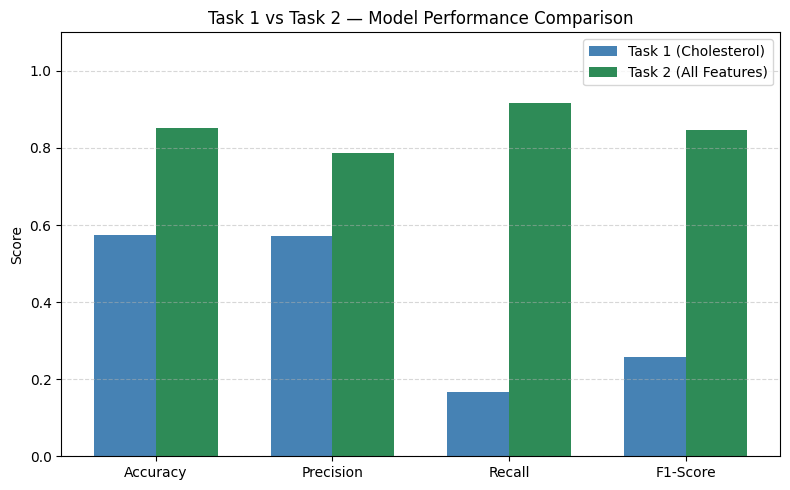

In [24]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Log Loss'],
    'Task 1 (Cholesterol only)': [acc1, prec1, rec1, f11, ll1],
    'Task 2 (All Features)':     [acc2, prec2, rec2, f12, ll2]
})
comparison = comparison.set_index('Metric').round(4)
print(comparison.to_string())

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
t1_vals = [acc1, prec1, rec1, f11]
t2_vals = [acc2, prec2, rec2, f12]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, t1_vals, width, label='Task 1 (Cholesterol)', color='steelblue')
ax.bar(x + width/2, t2_vals, width, label='Task 2 (All Features)', color='seagreen')
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Task 1 vs Task 2 — Model Performance Comparison')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Discussion

Task 2 shows a clear improvement over Task 1 because it considers all available clinical features rather than relying only on cholesterol

Using more features improves both accuracy and recall, as the model is able to identify more true positive cases of heart disease. More features generally reduce bias, but may increase variance if some variables are not relevant.

Task 1 is highly interpretable since it uses only one feature, but it underfits the data. Task 2 is more complex but much more predictive.

Overall, cholesterol alone is a weak predictor as it only performs slightly better than random chance, which is expected since heart disease is influenced by multiple factors.


Conclusion

This assignment applied a full machine learning pipeline to a binary classification problem. Task 1 showed that cholesterol alone has limited predictive power for heart disease, while Task 2 demonstrated that using multiple clinical features significantly improves performance.

Logistic regression is suitable for this task due to its probabilistic outputs, efficiency, and interpretability, and binary cross-entropy appropriately penalizes incorrect confident predictions.

Overall, the multi-feature model is more effective for practical use, offering better accuracy while remaining interpretable.
